The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


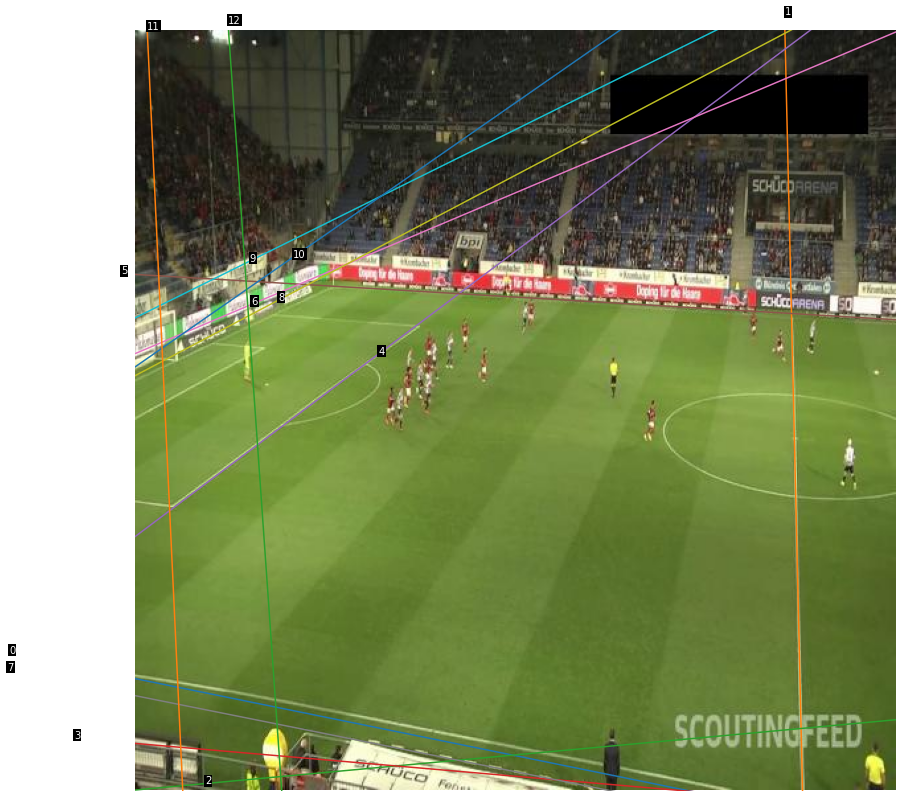

In [22]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.CocoDataset import CocoDataset
import matplotlib.pyplot as plt
from src.lineas import detectarLineas
from src.campo import mascaraCampo
from src.viz import dibujarLineas


CORRESPONDENCIAS = [
    ((232, 231), (16.5, 13.84)),   # A  esquina del área grande
    ((497, 219), (52.5,  0.0 )),   # C  medio campo × banda lejana
    ((492, 277), (52.5, 24.85)),   # D  círculo × medio campo, arriba
    ((505, 358), (52.5, 43.15)),   # E  círculo × medio campo, abajo
]

ds = CocoDataset("../data/raw/football-players/valid")
IMG_ID = 41
im = ds.imagen(IMG_ID)
msk = mascaraCampo(im)
rectas = detectarLineas(im, msk)


fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(im)
dibujarLineas(ax, rectas, *im.size)
ax.set_xlim(0, im.size[0])
ax.set_ylim(im.size[1], 0)
ax.axis("off")
plt.show()


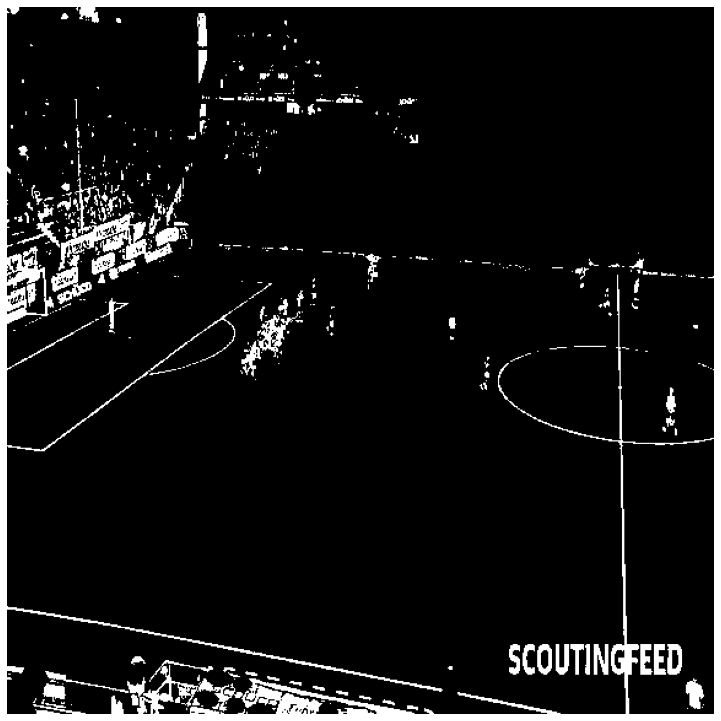

In [23]:
from src.lineas import realce
import numpy as np, cv2

th = realce(im)
th = np.where(msk, th, 0).astype(np.uint8)
_, binaria = cv2.threshold(th, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, ax = plt.subplots(figsize=(13, 13))
ax.imshow(binaria, cmap="gray")
ax.axis("off")
plt.show()

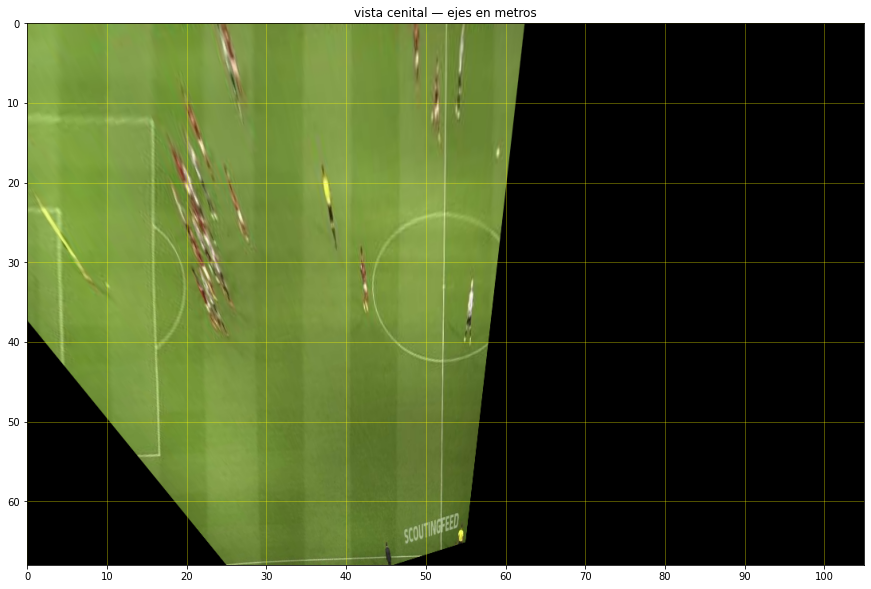

In [24]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from src.geometria import calcularHomografia

CORRESPONDENCIAS = [
    ((215, 228), (16.5, 13.84)),
    (( 30, 361), (16.5, 54.16)),
    ((498, 220), (52.5,  0.00)),
    ((499, 278), (52.5, 24.85)),
    ((504, 360), (52.5, 43.15)),
]

H, Hinv = calcularHomografia(CORRESPONDENCIAS)

ESCALA = 10                      # píxeles por metro
ANCHO, ALTO = int(105 * ESCALA), int(68 * ESCALA)

S = np.array([[ESCALA, 0, 0],
              [0, ESCALA, 0],
              [0, 0,      1]], dtype=np.float64)

cenital = cv2.warpPerspective(np.asarray(im), S @ H, (ANCHO, ALTO))

fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(cenital)
ax.set_xticks(range(0, ANCHO + 1, 10 * ESCALA))
ax.set_yticks(range(0, ALTO + 1, 10 * ESCALA))
ax.set_xticklabels(range(0, 106, 10))
ax.set_yticklabels(range(0, 69, 10))
ax.grid(True, color="yellow", alpha=0.4)
ax.set_title("vista cenital — ejes en metros")
plt.show()

In [25]:
from src.modelo import crearModelo
import torch

modelo = crearModelo(congelarBackbone=False,ligero=False)
modelo.load_state_dict(torch.load("../outputs/modelo_experimento_ResNet_20ep.pt", map_location=torch.device('cpu')))
modelo.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
from torchvision.transforms.functional import to_tensor
from src.geometria import puntoApoyo, aMetros
from torchvision.ops import nms

PERSONAS = {2, 3}
UMBRAL   = 0.50

x = to_tensor(ds.imagen(IMG_ID))

with torch.no_grad():
    pred = modelo([x])[0]

cajas = [
    b for b, l, s in zip(pred["boxes"].tolist(),
                         pred["labels"].tolist(),
                         pred["scores"].tolist())
    if int(l) in PERSONAS and s >= UMBRAL
]

puntos = []

for caja in cajas:
    puntos.append(puntoApoyo(caja))

metros = aMetros(H, puntos)                  

dentro = [(x, y) for x, y in metros if 0 <= x <= 105 and 0 <= y <= 68]
fuera  = [(x, y) for x, y in metros if not (0 <= x <= 105 and 0 <= y <= 68)]

print(len(metros), "detectados ->", len(dentro), "en el campo")

24 detectados -> 23 en el campo
24 tras filtrar -> 24 tras NMS


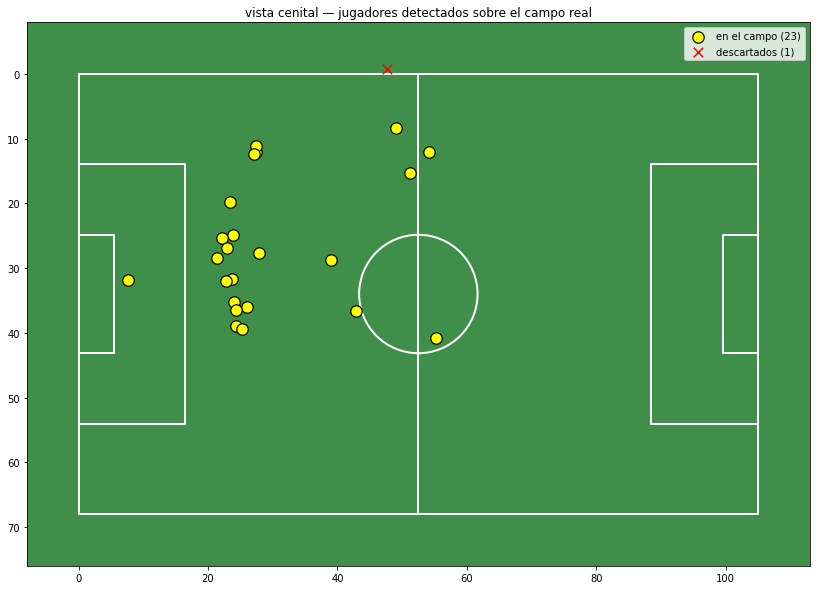

In [37]:
import numpy as np
import matplotlib.pyplot as plt

L, W = 105.0, 68.0

fig, ax = plt.subplots(figsize=(15, 10))

ax.plot([0, L, L, 0, 0], [0, 0, W, W, 0], color="white", lw=2)   
ax.plot([L/2, L/2], [0, W], color="white", lw=2)                  
ax.add_patch(plt.Circle((L/2, W/2), 9.15, fill=False, color="white", lw=2))
for x0, signo in ((0, 1), (L, -1)):                               
    ax.plot([x0, x0 + signo*16.5, x0 + signo*16.5, x0],
            [13.84, 13.84, 54.16, 54.16], color="white", lw=2)
    ax.plot([x0, x0 + signo*5.5, x0 + signo*5.5, x0],
            [24.84, 24.84, 43.16, 43.16], color="white", lw=2)

if dentro:
    xs, ys = zip(*dentro)
    ax.scatter(xs, ys, s=130, c="yellow", ec="black", lw=1.2, zorder=5,
               label=f"en el campo ({len(dentro)})")
if fuera:
    xs, ys = zip(*fuera)
    ax.scatter(np.clip(xs, -8, 113), np.clip(ys, -8, 76), s=90, c="red",
               marker="x", zorder=5, label=f"descartados ({len(fuera)})")

ax.set_facecolor("#3f8f4a")
ax.set_xlim(-8, 113)
ax.set_ylim(76, -8)
ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_title("vista cenital — jugadores detectados sobre el campo real")
plt.show()